In [ ]:
#we aim to detect faulty device on 47 features from sensors, used data 
#describing checking, visualizations, and null value checking

#LightGBM(gradient boosting) classfier has been used here due to its 
# best abiloty to work for structured data and provind best results 
#in our case.
#used stratified K-fold techniques and trained complete model on 
#best hyper parameters found using hyperparameter tuning
#Final results are stored in Final.csv file attached in the repository
#and a model is trained and attached along too

In [ ]:
#all the neccessary libraries are imported, LightGBM is our primary
#machine learning model which is a gradient boosting model works bset for
#numeric and structured data, sklearn is used for cross-validation and 
#evaluation metrics, seaborn is used to plot relationship between features

import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns

In [18]:
#loading the dataset, both training and testing datasets are loaded
#seperately and shape of each is printed to understand it
train_df = pd.read_csv("TRAIN.csv")
test_df = pd.read_csv("TEST.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (43776, 48)
Test shape: (10944, 48)


In [19]:
print(train_df.columns)

Index(['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10',
       'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20',
       'F21', 'F22', 'F23', 'F24', 'F25', 'F26', 'F27', 'F28', 'F29', 'F30',
       'F31', 'F32', 'F33', 'F34', 'F35', 'F36', 'F37', 'F38', 'F39', 'F40',
       'F41', 'F42', 'F43', 'F44', 'F45', 'F46', 'F47', 'Class'],
      dtype='str')


In [ ]:
#checking for any missing values 
print("Missing values in train:", train_df.isnull().sum().sum())
print("Missing values in test:", test_df.isnull().sum().sum())
#no null values were found thus it is safe to move ahead

Missing values in train: 0
Missing values in test: 0


In [ ]:
#understanding the class ratio , we have two classes 0 and 1 and we
#try to print the number of values of both classes
print(train_df["Class"].value_counts())
print(train_df["Class"].value_counts(normalize=True))

Class
0    26465
1    17311
Name: count, dtype: int64
Class
0    0.604555
1    0.395445
Name: proportion, dtype: float64


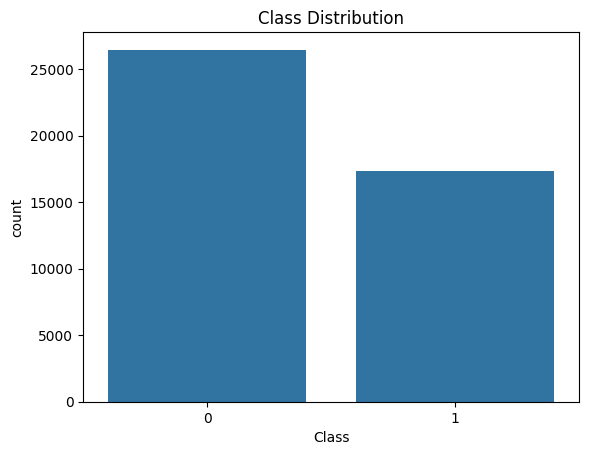

In [ ]:
#count plot made to visaluzie class distribution
sns.countplot(x=train_df["Class"])
plt.title("Class Distribution")
plt.show()

In [ ]:
#duplicates can affect performance. if there are dusplicates then same
#values can be used in training and tetsing causing wrong results
#we checked for duplicates in target and on targets both
print("Duplicates (with target):", train_df.duplicated().sum())
print("Duplicates (without target):",
      train_df.drop(columns=["Class"]).duplicated().sum())

Duplicates (with target): 738
Duplicates (without target): 738


In [ ]:
#removed the duplicate fields completely
train_df = train_df.drop_duplicates().reset_index(drop=True)

In [ ]:
#correlayion will help in understanding the relationship with target 
#variable, hence we checked each feature's correlation and
#extract top 10.
corr = train_df.corr()["Class"].abs().sort_values(ascending=False)
print(corr.head(10))

Class    1.000000
F01      0.382945
F09      0.372717
F29      0.360188
F19      0.355015
F21      0.344106
F05      0.341466
F25      0.338109
F07      0.332228
F27      0.332072
Name: Class, dtype: float64


In [ ]:
#preparing data to feed to the model
y = train_df["Class"]
X = train_df.drop(columns=["Class"])

test_id = test_df["ID"]
X_test = test_df.drop(columns=["ID"])

In [ ]:
#cross validation is done to divide the data into a split for test
#and training, we used stratified k fold with k=5 which means in
# each itertaion model will train on 4 fold and validate on 1
# stratified k fold maintains proportion of target class
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

In [ ]:
#training
#the model is trained using LightGBM, it works great for structured data 
#early stopping is used to stop and prevent overfitting.
#different parametrs are checked and hypertuned to get best results
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = LGBMClassifier(
        n_estimators=8000,
        learning_rate=0.01,
        num_leaves=64,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(0)
        ]
    )

    oof[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits

[LightGBM] [Info] Number of positive: 13849, number of negative: 20581
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009164 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11985
[LightGBM] [Info] Number of data points in the train set: 34430, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.402236 -> initscore=-0.396155
[LightGBM] [Info] Start training from score -0.396155
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3711]	valid_0's auc: 0.999359	valid_0's binary_logloss: 0.0312183
[LightGBM] [Info] Number of positive: 13849, number of negative: 20581
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004171 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11985
[LightGBM] [Info] Number of data points in the train set: 34430, number o

In [ ]:
#success metrics are extracted along with F1 scores 
oof_labels = (oof > 0.5).astype(int)

print("\n result")
print("accuracy:", accuracy_score(y, oof_labels))
print("Precision:", precision_score(y, oof_labels))
print("Recall:", recall_score(y, oof_labels))
print("F1Score:", f1_score(y, oof_labels))
print("ROC AUC:", roc_auc_score(y, oof))

print("\nConfusion matrix:")
print(confusion_matrix(y, oof_labels))

print("\nclasification  report:")
print(classification_report(y, oof_labels))


 result
accuracy: 0.9884288303359822
Precision: 0.9919246298788694
Recall: 0.9792039743515684
F1Score: 0.9855232558139535
ROC AUC: 0.9992795537764577

Confusion matrix:
[[25589   138]
 [  360 16951]]

clasification  report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     25727
           1       0.99      0.98      0.99     17311

    accuracy                           0.99     43038
   macro avg       0.99      0.99      0.99     43038
weighted avg       0.99      0.99      0.99     43038



In [ ]:
#After validation on K folded technique along with best hyperparameters,
#a complete model is trained on entire training dataset
final_model = LGBMClassifier(
    n_estimators=6000,
    learning_rate=0.01,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y)

[LightGBM] [Info] Number of positive: 17311, number of negative: 25727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008878 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11985
[LightGBM] [Info] Number of data points in the train set: 43038, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.402226 -> initscore=-0.396199
[LightGBM] [Info] Start training from score -0.396199


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,6000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
#the model is saved as a .pkl file
import joblib
joblib.dump(final_model, "f_model_10by10.pkl")

['f_model_10by10.pkl']

In [ ]:
#the results for the test.csv is saved into final.csv
final_probs = final_model.predict_proba(X_test)[:, 1]
final_preds = (final_probs > 0.5).astype(int)

sub = pd.DataFrame({
    "ID": test_id,
    "CLASS": final_preds
})

sub.to_csv("FINAL.csv", index=False)

print("FINAL.csv created successfully")

FINAL.csv created successfully
